# Notebook with the code necessary to perform the preprocessing for using NAS to solve AV

Luis Ignacio Ferro Salinas

Looking at default encoding

In [ ]:
import locale
locale.getencoding()

'UTF-8'

Dependencies

In [ ]:
%%capture

!pip install transformers[torch]
!pip install datasets
!pip install nltk==3.8.1
!pip install kneed
!pip install accelerate==0.24.1
!pip install -q gwpy



In [ ]:
def debug(thing, title):
    print("-------------------------------------------------------------------")
    print(title)
    print(thing)
    print("-------------------------------------------------------------------")

In [ ]:
from zipfile import ZipFile
from collections import Counter
import os
import json
import random
import pandas as pd
import numpy as np
import math
from datasets import Dataset, Features, Value, ClassLabel, IterableDataset
from transformers import AutoTokenizer
import torch
from transformers import AutoModel
import numpy as np
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings

warnings.filterwarnings(action = 'ignore')



from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, \
    BernoulliNB, CategoricalNB
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import pickle

import string
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report

In [ ]:
%%capture
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


# Preprocessing

We reference the path where we may save the preprocessed results (connected to google drive).

In [ ]:
path_to_save = os.path.join('drive', 'MyDrive', 'thesis', 'Preprocessed')

def fill_df(dictionary, df, authors=False):
    # Function to fill up a dataframe as an intermediate data form before
    # passing to BERT directly.
    problem_ids = []
    labels = []
    text1s = []
    text2s = []

    if authors == True:
        authors1 = []
        authors2 = []

    for key in dictionary:
        #row = pd.DataFrame(columns=['problem_id', 'text1', 'text2', 'label'])
        problem_ids += [key]
        text1s += [dictionary[key][1]]
        text2s += [dictionary[key][2]]
        labels += [dictionary[key][0]]

        if authors == True:
            authors1 += [dictionary[key][3]]
            authors2 += [dictionary[key][4]]
        #print(row)
        #df = pd.concat([df, row])
        #debug(df.shape, 'shape')

    if authors == True:
        return df.from_dict({'problem_id': problem_ids, 'text1': text1s,
                         'text2': text2s, 'label': labels, 'author1': authors1, 'author2': authors2})
    return df.from_dict({'problem_id': problem_ids, 'text1': text1s,
                         'text2': text2s, 'label': labels})

This section focuses on the initial data preparation, establishing a consistent structure across all datasets. It outlines the process of creating a unified dictionary where each problem is uniquely identified, storing its binary label, the provided known text, and the text requiring prediction. Finally, it details the transformation of this dictionary into a Pandas DataFrame for efficient manipulation and its subsequent saving as a CSV file, ensuring a standardized input format for downstream analysis.

## PAN 2013

In [ ]:
'''path_to_pan2013_training = os.path.join('drive', 'MyDrive', 'thesis',
            'pan13-authorship-verification-test-and-training',
            'pan13-authorship-verification-training-corpus-2013-02-01',
            'English')

path_to_pan2013_testing = os.path.join('drive', 'MyDrive', 'thesis',
            'pan13-authorship-verification-test-and-training',
            'pan13-authorship-verification-test-corpus2-2013-05-29',
            'English')
'''
path_to_pan2013_training = os.path.join('drive', 'MyDrive', 'thesis',
            'pan13-authorship-verification-test-and-training',
            'pan13-authorship-verification-training-corpus-2013-02-01',
            'Spanish')

path_to_pan2013_testing = os.path.join('drive', 'MyDrive', 'thesis',
            'pan13-authorship-verification-test-and-training',
            'pan13-authorship-verification-test-corpus2-2013-05-29',
            'Spanish')






In [ ]:
# PAN 2013

x_train = []
y_train = []

x_test = []
y_test = []

training_dict = {}
testing_dict = {}


# Fill labels in dicitionary
def fill_lid(truth_file, dictionary):
    truths = truth_file.readlines()
    for truth in truths:
        problem_id, label = truth.split()
        label = '1' if label == 'Y' else '0'
        dictionary[problem_id] = [label, None, None]

# Fill texts in dictionary
# unknown text file
def fill_utid(utext_file, problem_id, dictionary):
    utext_str = utext_file.read()
    dictionary[problem_id][2] = utext_str

def fill_ktid(ktext_file, problem_id, dictionary):
    ktext_str = ktext_file.read()
    dictionary[problem_id][1] = ktext_str


with open(os.path.join(path_to_pan2013_training, 'truth.txt'), 'r') as truth_file:
    fill_lid(truth_file, training_dict)

with open(os.path.join(path_to_pan2013_testing, 'truth.txt'), 'r') as truth_file:
    fill_lid(truth_file, testing_dict)

def fill_dictionary(data_split):
    if data_split == 'training':
        path_to_pan = path_to_pan2013_training
        dictionary = training_dict
    else:
        path_to_pan = path_to_pan2013_testing
        dictionary = testing_dict


    for problem_folder in os.listdir(path_to_pan):
        if problem_folder == 'truth.txt' or problem_folder == 'contents.json':
            continue

        print(f"for problem {problem_folder}")
        path_to_problem = os.path.join(path_to_pan, problem_folder)

        # Maximum known document length
        # Longest kown document name

        max_kdlen = 0
        longest_kdn = ''
        # Text file name
        for text_filen in os.listdir(path_to_problem):
            with open(os.path.join(path_to_problem, text_filen), 'r') as \
                text_file:
                if 'unknown' in text_filen:
                    fill_utid(text_file, problem_folder, dictionary)

                else:
                    kd_content = text_file.read()
                    kd_len = len(kd_content)

                    if kd_len > max_kdlen:
                        max_kdlen = kd_len
                        longest_kdn = text_filen
                    debug(max_kdlen, 'current max length')
        debug(longest_kdn, 'longest file')


        with open(os.path.join(path_to_problem, longest_kdn)) as kd_file:
            fill_ktid(kd_file, problem_folder, dictionary)


fill_dictionary('training')
fill_dictionary('testing')


for problem SP05
-------------------------------------------------------------------
current max length
3665
-------------------------------------------------------------------
-------------------------------------------------------------------
current max length
3714
-------------------------------------------------------------------
-------------------------------------------------------------------
current max length
3714
-------------------------------------------------------------------
-------------------------------------------------------------------
longest file
known01.txt
-------------------------------------------------------------------
for problem SP02
-------------------------------------------------------------------
current max length
3600
-------------------------------------------------------------------
-------------------------------------------------------------------
current max length
5545
-------------------------------------------------------------------
-----

In [ ]:
training_data2013 = pd.DataFrame(columns=['problem_id',
                                           'text1', 'text2', 'label'])
testing_data2013 = pd.DataFrame(columns=['problem_id',
                                          'text1', 'text2', 'label'])


In [ ]:
training_data2013 = fill_df(training_dict, training_data2013)
testing_data2013 = fill_df(testing_dict, testing_data2013)

In [ ]:
training_data2013.head()

,problem_id,text1,text2,label
0,SP02,La nueva Miss Universo es rusa y trabaja de po...,El ciberespacio ha dado bríos a un género tris...,1
1,SP03,En un mundo dispar llama la atención que la ge...,Si México tuviera un régimen parlamentario y n...,0
2,SP05,Varias semanas antes de que Néstor apareciera ...,En el mismo momento en que el cadáver de Nésto...,1
3,SP09,Tenía los bigotes más rígidos que nunca; tanto...,Lönnrot se abstuvo de sonreír. Bruscamente bib...,0
4,SP10,El regreso de Julián me afecta menos de lo que...,Poco a poco fuimos entrando a otro clima.\nLa ...,1


In [ ]:
testing_data2013.head()

,problem_id,text1,text2,label
0,SP01,Los chinos son el peligro amarillo.\nEl nombre...,Usted debe haber visto el Coliseo romano en al...,1
1,SP04,Era inevitable : el olor de las almendras amar...,Era la primera vez que hacía el amor en más de...,1
2,SP06,Aguilar dice que desde que su mujer está extra...,Los campesinos en los alrededores de la finca ...,0
3,SP07,Llevado por el entusiasmo de su celo vocaciona...,...- Lo importante es que te vayas a gusto ¿Te...,0
4,SP08,Todavía no se atreve a definir ante sí mismo e...,"Sensación de bochorno, había sido el anuncio m...",1


In [ ]:
# training_data2013.to_csv(os.path.join(path_to_save, 'training_data2013Es.csv'), index=False, sep='\\')
# testing_data2013.to_csv(os.path.join(path_to_save, 'testing_data2013Es.csv'), index=False, sep='\\')

In [ ]:
training_data2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   problem_id  5 non-null      object
 1   text1       5 non-null      object
 2   text2       5 non-null      object
 3   label       5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes


In [ ]:
testing_data2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   problem_id  25 non-null     object
 1   text1       25 non-null     object
 2   text2       25 non-null     object
 3   label       25 non-null     object
dtypes: object(4)
memory usage: 932.0+ bytes


## PAN 2014

In [ ]:
# A lot of variations here, 2 test corpora, for english 2 corpora in training
# and test, to keep discourse type same I guess.

# path_to_pan2014_training = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-training-corpus-2014-04-22',
#              'pan14-author-verification-training-corpus-english-essays-2014-04-22')

path_to_pan2014_training = os.path.join('drive', 'MyDrive', 'thesis',
            'pan14-authorship-verification-test-and-training',
            'pan14-authorship-verification-training-corpus-2014-04-22',
            'pan14-author-verification-training-corpus-english-novels-2014-04-22')


# path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-test-corpus1-2014-04-22',
#             'pan14-author-verification-test-corpus1-english-essays-2014-04-22')

# path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-test-corpus1-2014-04-22',
#             'pan14-author-verification-test-corpus1-english-novels-2014-04-22')

# path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-test-corpus2-2014-04-22',
#             'pan14-author-verification-test-corpus2-english-essays-2014-04-22')

path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
            'pan14-authorship-verification-test-and-training',
            'pan14-authorship-verification-test-corpus2-2014-04-22',
            'pan14-author-verification-test-corpus2-english-novels-2014-04-22')



# path_to_pan2014_training = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-training-corpus-2014-04-22',
#             'pan14-author-verification-training-corpus-spanish-articles-2014-04-22')

# path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-test-corpus1-2014-04-22',
#             'pan14-author-verification-test-corpus1-spanish-articles-2014-04-22')

# path_to_pan2014_testing = os.path.join('drive', 'MyDrive', 'thesis',
#             'pan14-authorship-verification-test-and-training',
#             'pan14-authorship-verification-test-corpus2-2014-04-22',
#             'pan14-author-verification-test-corpus2-spanish-articles-2014-04-22')



In [ ]:
# PAN 2014

x_train = []
y_train = []

x_test = []
y_test = []

training_dict = {}
testing_dict = {}


# Fill labels in dictionary
def fill_lid(truth_file, dictionary):
    truths = truth_file.readlines()
    for truth in truths:
        problem_id, label = truth.split()
        label = '1' if label == 'Y' else '0'
        dictionary[problem_id] = [label, None, None]

# Fill texts in dictionary
# unknown text file
def fill_utid(utext_file, problem_id, dictionary):
    utext_str = utext_file.read()
    dictionary[problem_id][2] = utext_str

def fill_ktid(ktext_file, problem_id, dictionary):
    ktext_str = ktext_file.read()
    dictionary[problem_id][1] = ktext_str


with open(os.path.join(path_to_pan2014_training, 'truth.txt'), 'r', encoding='utf-8-sig') as truth_file:
    fill_lid(truth_file, training_dict)

with open(os.path.join(path_to_pan2014_testing, 'truth.txt'), 'r', encoding='utf-8-sig') as truth_file:
    fill_lid(truth_file, testing_dict)

def fill_dictionary(data_split):
    if data_split == 'training':
        path_to_pan = path_to_pan2014_training
        dictionary = training_dict
    else:
        path_to_pan = path_to_pan2014_testing
        dictionary = testing_dict


    for problem_folder in os.listdir(path_to_pan):
        if problem_folder == 'truth.txt' or problem_folder == 'contents.json' \
        or problem_folder == 'truth.json':
            continue

        print(f"for problem {problem_folder}")
        path_to_problem = os.path.join(path_to_pan, problem_folder)

        # Maximum known document length
        # Longest kown document name

        max_kdlen = 0
        longest_kdn = ''
        # Text file name
        for text_filen in os.listdir(path_to_problem):
            with open(os.path.join(path_to_problem, text_filen), 'r') as \
                text_file:
                if 'unknown' in text_filen:
                    fill_utid(text_file, problem_folder, dictionary)

                else:
                    kd_content = text_file.read()
                    kd_len = len(kd_content)

                    if kd_len > max_kdlen:
                        max_kdlen = kd_len
                        longest_kdn = text_filen
                    debug(max_kdlen, 'current max length')
        debug(longest_kdn, 'longest file')


        with open(os.path.join(path_to_problem, longest_kdn)) as kd_file:
            fill_ktid(kd_file, problem_folder, dictionary)


fill_dictionary('training')
fill_dictionary('testing')


for problem EN033
-------------------------------------------------------------------
current max length
4731
-------------------------------------------------------------------
-------------------------------------------------------------------
longest file
known01.txt
-------------------------------------------------------------------
for problem EN002
-------------------------------------------------------------------
current max length
82747
-------------------------------------------------------------------
-------------------------------------------------------------------
longest file
known01.txt
-------------------------------------------------------------------
for problem EN005
-------------------------------------------------------------------
current max length
23104
-------------------------------------------------------------------
-------------------------------------------------------------------
longest file
known01.txt
-------------------------------------------------

In [ ]:
training_data2014 = pd.DataFrame(columns=['problem_id',
                                           'text1', 'text2', 'label'])
testing_data2014 = pd.DataFrame(columns=['problem_id',
                                          'text1', 'text2', 'label'])

In [ ]:
training_data2014 = fill_df(training_dict, training_data2014)
testing_data2014 = fill_df(testing_dict, testing_data2014)

In [ ]:
training_data2014.head()

,problem_id,text1,text2,label
0,EN001,"﻿The world we live in is not as it seems. I, J...",VII.\n\nYet all this was only the prologue of ...,0
1,EN002,V. A Nightmare and a Cataclysm\n\n1.\n\nAnd no...,"II.\n\nIt was in the township of Dunwich, in a...",1
2,EN003,III. A Search and an Evocation\n\n1.\n\nCharle...,"﻿April 20th, 1909\nThey have given me one hour...",0
3,EN004,"﻿Birth Right\nMantineus-I'm more Mr. Briggs, t...","﻿The Judas Mark\n""Cthulhu ftaghn,"" He said wit...",1
4,EN005,﻿An autumnal chill descended upon the streets ...,"﻿May 19th, 1929,\nMiskatonic University, Arkha...",1


In [ ]:
testing_data2014.head()

,problem_id,text1,text2,label
0,EN101,﻿I can hardly describe the mood in which I was...,﻿Only when the Nan-yang Maru sailed from Yuen-...,0
1,EN102,﻿I can hardly describe the mood in which I was...,﻿\nBy Their smell can men sometimes know Them ...,0
2,EN103,﻿When I drew nigh the nameless city I knew it ...,﻿(Found Among the Papers of the Late\nFrancis ...,1
3,EN104,﻿I WAS SITTING on the porch when my grandfathe...,"﻿On the wall hung a map of Mongolia, that inde...",0
4,EN105,"﻿\n\n ""Oh, thou who burn'st in heart for thos...","﻿It is said that in Ulthar, which lies beyond ...",0


In [ ]:
# training_data2014.to_csv(os.path.join(path_to_save, 'training_data2014EnNovel.csv'), index=False, sep='\\')
# testing_data2014.to_csv(os.path.join(path_to_save, 'testing_data2014EnNovel2.csv'), index=False, sep='\\')

In [ ]:
testing_data2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   problem_id  200 non-null    object
 1   text1       200 non-null    object
 2   text2       200 non-null    object
 3   label       200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


## PAN 2015

In [ ]:
'''path_to_pan2015_training = os.path.join('drive', 'MyDrive', 'thesis',
            'pan15-authorship-verification-test-and-training',
            'pan15-authorship-verification-training-dataset-2015-04-19',
            'pan15-authorship-verification-training-dataset-english-2015-04-19')

path_to_pan2015_testing = os.path.join('drive', 'MyDrive', 'thesis',
            'pan15-authorship-verification-test-and-training',
            'pan15-authorship-verification-test-dataset2-2015-04-19',
            'pan15-authorship-verification-test-dataset2-english-2015-04-19')
'''
path_to_pan2015_training = os.path.join('drive', 'MyDrive', 'thesis',
            'pan15-authorship-verification-test-and-training',
            'pan15-authorship-verification-training-dataset-2015-04-19',
            'pan15-authorship-verification-training-dataset-spanish-2015-04-19')

path_to_pan2015_testing = os.path.join('drive', 'MyDrive', 'thesis',
            'pan15-authorship-verification-test-and-training',
            'pan15-authorship-verification-test-dataset2-2015-04-19',
            'pan15-authorship-verification-test-dataset2-spanish-2015-04-19')





In [ ]:
# PAN 2015

x_train = []
y_train = []

x_test = []
y_test = []

training_dict = {}
testing_dict = {}


# Fill labels in dicitionary
def fill_lid(truth_file, dictionary):
    truths = truth_file.readlines()
    for truth in truths:
        problem_id, label = truth.split()
        label = '1' if label == 'Y' else '0'
        dictionary[problem_id] = [label, None, None]

# Fill texts in dictionary
# unknown text file
def fill_utid(utext_file, problem_id, dictionary):
    utext_str = utext_file.read()
    dictionary[problem_id][2] = utext_str

def fill_ktid(ktext_file, problem_id, dictionary):
    ktext_str = ktext_file.read()
    dictionary[problem_id][1] = ktext_str


with open(os.path.join(path_to_pan2015_training, 'truth.txt'), 'r') as truth_file:
    fill_lid(truth_file, training_dict)

with open(os.path.join(path_to_pan2015_testing, 'truth.txt'), 'r') as truth_file:
    fill_lid(truth_file, testing_dict)

def fill_dictionary(data_split):
    if data_split == 'training':
        path_to_pan = path_to_pan2015_training
        dictionary = training_dict
    else:
        path_to_pan = path_to_pan2015_testing
        dictionary = testing_dict


    for problem_folder in os.listdir(path_to_pan):
        if problem_folder == 'truth.txt' or problem_folder == 'contents.json':
            continue
        path_to_problem = os.path.join(path_to_pan, problem_folder)

        # Maximum known document length
        # Longest kown document name
        print(f"for problem {problem_folder}")
        max_kdlen = 0
        longest_kdn = ''
        # Text file name
        for text_filen in os.listdir(path_to_problem):
            with open(os.path.join(path_to_problem, text_filen), 'r') as \
                text_file:
                if 'unknown' in text_filen:
                    fill_utid(text_file, problem_folder, dictionary)

                else:
                    kd_content = text_file.read()
                    kd_len = len(kd_content)

                    if kd_len > max_kdlen:
                        max_kdlen = kd_len
                        longest_kdn = text_filen
                    print(max_kdlen, 'current max length')

        debug(longest_kdn, 'longest file')
        with open(os.path.join(path_to_problem, longest_kdn)) as kd_file:
            fill_ktid(kd_file, problem_folder, dictionary)


fill_dictionary('training')
fill_dictionary('testing')


for problem SP025
4630 current max length
4669 current max length
4809 current max length
4809 current max length
-------------------------------------------------------------------
longest file
known04.txt
-------------------------------------------------------------------
for problem SP014
4630 current max length
4779 current max length
4795 current max length
4795 current max length
-------------------------------------------------------------------
longest file
known04.txt
-------------------------------------------------------------------
for problem SP013
6288 current max length
6288 current max length
6506 current max length
6506 current max length
-------------------------------------------------------------------
longest file
known04.txt
-------------------------------------------------------------------
for problem SP022
6245 current max length
6545 current max length
6545 current max length
6751 current max length
-------------------------------------------------------------

In [ ]:
def debug_dictionary(dictionary):
    for key in dictionary:
        print(key, dictionary[key][0], len(dictionary[key][1]),
              len(dictionary[key][2]))


In [ ]:
training_data2015 = pd.DataFrame(columns=['problem_id',
                                           'text1', 'text2', 'label'])
testing_data2015 = pd.DataFrame(columns=['problem_id',
                                          'text1', 'text2', 'label'])


In [ ]:
training_data2015 = fill_df(training_dict, training_data2015)
testing_data2015 = fill_df(testing_dict, testing_data2015)

In [ ]:
training_data2015.head()

,problem_id,text1,text2,label
0,SP001,"﻿Sobre miedo, periodismo y libertad\nHace medi...",﻿Baile agarrado e ira de Dios\nMe ha discutido...,1
1,SP002,"﻿Una década o Khety tenía razón\nEn la Tjel, c...",﻿El pasado omnipresente\n¿Qué pasaría si hecho...,0
2,SP003,﻿Especialistas del desprecio\nLa semana pasada...,﻿Tres números y tres letras\nCon cariño para G...,1
3,SP004,"﻿Noelia, historia de una promesa cumplida\n“Pa...",﻿Tres números y tres letras\nCon cariño para G...,1
4,SP005,"﻿Capitanes valientes, o no\nLa noche del 14 de...",﻿La pizzera de Nápoles\nHe leído estos días Ie...,1


In [ ]:
testing_data2015.head()

,problem_id,text1,text2,label
0,SP001,﻿El primer tercio y la gran crisis\nNúmeros y ...,"﻿Mexico, su estado y los cuasi estados\nDesapa...",1
1,SP002,﻿El primer tercio y la gran crisis\nNúmeros y ...,"﻿Mexico, su estado y los cuasi estados\nDesapa...",1
2,SP003,﻿Ciudadanos descreídos\nEl problema más serio ...,"﻿Fabricación de ""violentos""\nAlejandro Cabrera...",0
3,SP004,﻿¿Hasta dónde la violencia?\nHace unos días el...,"﻿Preguntas a nosotros mismos\nEstimad@ lector,...",1
4,SP005,﻿Corrupción entre los incorruptibles\nCuando s...,﻿La insidiosa certidumbre\nEl Pacto por México...,1


In [ ]:
# training_data2015.to_csv(os.path.join(path_to_save, 'training_data2015Es.csv'), index=False, sep='\\')
# testing_data2015.to_csv(os.path.join(path_to_save, 'testing_data2015Es.csv'), index=False, sep='\\')

In [ ]:
training_data2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   problem_id  100 non-null    object
 1   text1       100 non-null    object
 2   text2       100 non-null    object
 3   label       100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [ ]:
testing_data2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   problem_id  100 non-null    object
 1   text1       100 non-null    object
 2   text2       100 non-null    object
 3   label       100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [ ]:
X_train = []
for problem_id in training_dict.keys():
    text1, text2 = training_dict[problem_id]
    X_train += [text1]
    X_train += [text2]

In [ ]:
show_info(X_train)

0
100


(5282, 220.61999999999998, 98.435)

In [ ]:
debug(len(training_dict), 'training examples')
debug(len(testing_dict), 'testing examples')

NameError: ignored

In [ ]:
# label and length of document
"""def show_lld(data_split):
    i = 0
    if data_split == 'training':
        dataset = training_dict
    else:
        dataset = testing_dict
    for problem_id in training_dict:
        #debug(len(training_dict[problem_id]), 'number elements in training')
        i += 1
        ex1, ex2 = training_dict[problem_id]

        #print(ex2)
        ex1_label, ex1_text = ex1

        ex2_label, ex2_text = ex2
        debug((ex1_label, len(ex1_text.split())), f'example {problem_id} label and doc length')
        debug((ex2_label, len(ex2_text.split())), f'example {problem_id} label and doc length')
        if i == 5:
            break"""

In [ ]:
"""show_lld('testing')"""

In [ ]:
"""len(testing_dict)"""

500

In [ ]:
"""x_train = []
y_train = []

x_test = []
y_test = []
for data_split in [training_dict, testing_dict]:
    for problem_id in data_split:
        for example in data_split[problem_id]:
            label, text = example
            #print(label, len(text))
            if data_split == training_dict:
                x_train += [text]
                y_train += [label]
            else:
                x_test += [text]
                y_test += [label]"""

In [ ]:
"""debug(len(x_train), 'n examples')"""
"""debug(len(y_train), 'n labels')"""

----------------------------------------------------------------------
n examples
200
----------------------------------------------------------------------
----------------------------------------------------------------------
n labels
200
----------------------------------------------------------------------


## PAN 2020-21

In [ ]:
path_to_pan2020_training = os.path.join('drive', 'MyDrive', 'thesis',
                               'pan20-authorship-verification-test-and-training',
                                'pan20-authorship-verification-training-small')

path_to_pan2020_testing = os.path.join('drive', 'MyDrive', 'thesis',
                               'pan20-authorship-verification-test-and-training',
                                'pan20-authorship-verification-test')


In [ ]:
# PAN 2020(21)

training_data2020 = pd.DataFrame(columns=['problem_id', 'text1', 'text2',
                                           'label', 'author1', 'author2'])

training_dict2020 = dict()
testing_dict2020 = dict()

x_train = []
y_train = []


# fill data labels
def fill_lid2020(dictionary, problem_id, authors):

    if authors[0] == authors[1]:
        dictionary[problem_id] = [1, None, None, authors[0], authors[1]]
        #y_train += [1]
    else:
        dictionary[problem_id] = [0, None, None, authors[0], authors[1]]
        #y_train += [0]

def fill_texts2020(dictionary, problem_id, texts):
    text1, text2 = texts
    dictionary[problem_id][1] = text1
    dictionary[problem_id][2] = text2

def fill_dictionary2020(data_split):
    authors_list = []

    if data_split == 'training':
        path_to_pan2020 = path_to_pan2020_training
        dictionary = training_dict2020
        file_prefix = 'pan20-authorship-verification-training-small'
        n_rows = 50000
    else:
        path_to_pan2020 = path_to_pan2020_testing
        dictionary = testing_dict2020
        file_prefix = 'pan20-authorship-verification-test'
        n_rows = 14311

    with open(os.path.join(path_to_pan2020,
                    file_prefix + '-truth.jsonl')) \
                        as jsons_file:
        for i in range(n_rows):
            #if i % 1000 == 0:
                #print(i)
            json_str = jsons_file.readline()
            json_obj = json.loads(json_str)
            problem_id = json_obj['id']
            authors = json_obj['authors']
            authors_list += [authors[0]]
            authors_list += [authors[1]]
            fill_lid2020(dictionary, problem_id, authors)

    with open(os.path.join(path_to_pan2020, \
                        file_prefix + '.jsonl')) \
                        as jsons_file:
        for i in range(n_rows):
            if i % 1000 == 0:
                debug(i, 'problem index')
            json_str = jsons_file.readline()
            #if i < 10 or i > 49984:
            #    ...
            #else:
            #    continue
            json_obj = json.loads(json_str)
            problem_id = json_obj['id']

            texts = json_obj['pair']
            fill_texts2020(dictionary, problem_id, texts)
            #x_train += [texts]






In [ ]:
fill_dictionary2020('testing')
fill_dictionary2020('training')

-------------------------------------------------------------------
problem index
0
-------------------------------------------------------------------
-------------------------------------------------------------------
problem index
1000
-------------------------------------------------------------------
-------------------------------------------------------------------
problem index
2000
-------------------------------------------------------------------
-------------------------------------------------------------------
problem index
3000
-------------------------------------------------------------------
-------------------------------------------------------------------
problem index
4000
-------------------------------------------------------------------
-------------------------------------------------------------------
problem index
5000
-------------------------------------------------------------------
-------------------------------------------------------------------
probl

In [ ]:
training_data2020 = pd.DataFrame(columns=['problem_id',
                                           'text1', 'text2', 'label', 'author1', 'author2'])
testing_data2020 = pd.DataFrame(columns=['problem_id',
                                          'text1', 'text2', 'label', 'author1', 'author2'])

training_data2020 = fill_df(training_dict2020, training_data2020, authors=True)
testing_data2020 = fill_df(testing_dict2020, testing_data2020, authors=True)

In [ ]:
training_data2020.shape

(49989, 6)

In [ ]:
# testing_data2020.to_csv(os.path.join(path_to_save, 'testing_data2020.csv'), index=False, sep='\\')
# training_data2020.to_csv(os.path.join(path_to_save, 'training_data2020.csv'), index=False, sep='\\')



In [ ]:
training_data2020.head()

,problem_id,text1,text2,label,author1,author2
0,6cced668-6e51-5212-873c-717f2bc91ce6,"I shift a bit, warily letting my eyes dart fro...","""All will become one with Russia,"" he said, al...",1,1446633,1446633
1,3c6c188a-db28-59aa-8c09-3d0f799ff579,"I shift a bit, warily letting my eyes dart fro...","Suddenly, a piece of ice falls into the pit of...",1,1446633,1446633
2,b0cfa94f-c9ec-5aa5-8331-a5a249b664cf,A single tear escaped me as I left. I did have...,"got the Yang yoyo."" Kimiko pulled the other ha...",1,1446633,1446633
3,e6e86e73-9a7b-58f2-a652-a17b4a1bcabf,"""Ja."" Ludwig kept his gaze upon her, solidly. ...",SilverGray lll...YellowRagged llll...GrayMilli...,1,1446633,1446633
4,4fe541af-912e-5a86-81a5-94c6d3891509,"And he did. Slowly, hesitantly...but coming fr...","""Let""s go,"" Raimondo said and then started in ...",1,1446633,1446633


## Combined dataset

We created a combined dataset to have as a reference during initial tests.

In [ ]:
# This will combine the datasets of years (2013, 2014, 2015) and the
# reduced dataset from 2020 into one big guy for English

training_data2020s = pd.read_csv(os.path.join(path_to_save,
                                            'training_data2020s.csv'), sep='\\')
testing_data2020s = pd.read_csv(os.path.join(path_to_save,
                                        'testing_data2020s.csv'), sep='\\')



training_data2015En = pd.read_csv(os.path.join(path_to_save,
                                        'training_data2015En.csv'), sep='\\')
testing_data2015En = pd.read_csv(os.path.join(path_to_save,
                                    'testing_data2015En.csv'), sep='\\')

training_data2013En = pd.read_csv(os.path.join(path_to_save,
                                        'training_data2013En.csv'), sep='\\')
testing_data2013En = pd.read_csv(os.path.join(path_to_save,
                                    'testing_data2013En.csv'), sep='\\')

training_data2014EnNovel = pd.read_csv(os.path.join(path_to_save,
                                        f'training_data2014EnNovel.csv'), sep='\\')
testing_data2014EnNovel1 = pd.read_csv(os.path.join(path_to_save,
                                    f'testing_data2014EnNovel1.csv'), sep='\\')

testing_data2014EnNovel2 = pd.read_csv(os.path.join(path_to_save,
                                    f'testing_data2014EnNovel2.csv'), sep='\\')

training_data2014EnEssay = pd.read_csv(os.path.join(path_to_save,
                                        f'training_data2014EnEssay.csv'), sep='\\')
testing_data2014EnEssay1 = pd.read_csv(os.path.join(path_to_save,
                                    f'testing_data2014EnEssay1.csv'), sep='\\')

testing_data2014EnEssay2 = pd.read_csv(os.path.join(path_to_save,
                                    f'testing_data2014EnEssay2.csv'), sep='\\')

big_guy_training = pd.concat([training_data2013En, training_data2014EnNovel,
                              training_data2014EnEssay, training_data2015En,
                              training_data2020s])

big_guy_test = pd.concat([testing_data2013En, testing_data2014EnNovel1, testing_data2014EnNovel2,
                          testing_data2014EnEssay1, testing_data2014EnEssay2,
                          testing_data2015En, testing_data2020s])


print(big_guy_training.info())
print(big_guy_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 0 to 69
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   problem_id  480 non-null    object 
 1   text1       480 non-null    object 
 2   text2       480 non-null    object 
 3   label       480 non-null    float64
 4   author1     70 non-null     float64
 5   author2     70 non-null     float64
dtypes: float64(3), object(3)
memory usage: 26.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   problem_id  1160 non-null   object 
 1   text1       1160 non-null   object 
 2   text2       1160 non-null   object 
 3   label       1160 non-null   int64  
 4   author1     30 non-null     float64
 5   author2     30 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 63.4+ KB
None


In [ ]:
#big_guy_training.to_csv(os.path.join(path_to_save, 'big_guy_training.csv'), index=False, sep='\\')
#big_guy_test.to_csv(os.path.join(path_to_save, 'big_guy_test.csv'), index=False, sep='\\')


### Combined with random split

We also created a random split after concatenating the training and test sets to have an alternative and more diverse combined dataset.

In [ ]:
big_guy_training = pd.read_csv(os.path.join(path_to_save, 'big_guy_training.csv'), sep='\\')
big_guy_test = pd.read_csv(os.path.join(path_to_save, 'big_guy_test.csv'), sep='\\')

In [ ]:
print(big_guy_training.shape)
print(big_guy_test.shape)

(480, 6)
(1160, 6)


A random split from the concatenation of training/test sets.

In [ ]:
# merge training test
merge_tt = pd.concat([big_guy_training, big_guy_test])

# training split
n_total = len(merge_tt)
training_s = int(n_total * 0.8)
#test_s = n_total - training_s

training_bgrs = merge_tt.sample(n=training_s)

mask_in_training = merge_tt.index.isin(training_bgrs.index)

test_bgrs = merge_tt[~mask_in_training]

print(training_bgrs.shape)
print(test_bgrs.shape)

(1312, 6)
(171, 6)


In [ ]:
# training_bgrs.to_csv(os.path.join(path_to_save, 'training_bgrs.csv'), index=False, sep='\\')
# test_bgrs.to_csv(os.path.join(path_to_save, 'test_bgrs.csv'), index=False, sep='\\')

## Processing data from checkpoint files

## Define year and language and chunks

In [ ]:
year = 2015
language = "En"
test_set = 2
domain = 'Essay'
# test set only applies to the 2014 where there are 2 test sets
# domain only applies to 2014 English, where we have Novel and essay domains

In [ ]:
if year == 2020:
    ...
    '''training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2020.csv'), sep='\\')
    testing_data = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2020.csv'), sep='\\')'''
elif year == 2015:
    if language == "En":
        training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2015En.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2015En.csv'), sep='\\')

    elif language == "Es":
        training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2015Es.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2015Es.csv'), sep='\\')
elif year == 2013:
    if language == "En":
        training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2013En.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2013En.csv'), sep='\\')

    elif language == "Es":
        training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2013Es.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2013Es.csv'), sep='\\')
elif year == 2014:
    if language == "En":

        training_data = pd.read_csv(os.path.join(path_to_save,
                                             f'training_data2014En{domain}.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            f'testing_data2014En{domain}{test_set}.csv'), sep='\\')

    elif language == "Es":
        training_data = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2014Es.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                            f'testing_data2014Es{test_set}.csv'), sep='\\')


### SUBSET 2020 DATA

For the data from 2020, we reduced the number of examples to have a size comparable to the other datasets.

In [ ]:

def subset_data(df, rn_examples):
    example_is = set()
    for i in range(rn_examples):
        example_i = random.randint(0, df.shape[0])
        #print(example_i)
        if example_i in example_is:
            continue
        example_is.add(example_i)
    #print(list(example_is))
    return df.iloc[list(example_is)]

In [ ]:
training_data2020s = subset_data(training_data2020, 70)
testing_data2020s = subset_data(testing_data2020, 30)

In [ ]:
debug(training_data2020s.shape, 'shape sub training')
debug(testing_data2020s.shape, 'shape sub testing')

-------------------------------------------------------------------
shape sub training
(70, 6)
-------------------------------------------------------------------
-------------------------------------------------------------------
shape sub testing
(30, 6)
-------------------------------------------------------------------


In [ ]:
debug(training_data2020s['label'].value_counts(), 'training label counts')

debug(testing_data2020s['label'].value_counts(), 'testing label counts')

-------------------------------------------------------------------
training label counts
label
0    37
1    33
Name: count, dtype: int64
-------------------------------------------------------------------
-------------------------------------------------------------------
testing label counts
label
0    18
1    12
Name: count, dtype: int64
-------------------------------------------------------------------


In [ ]:
# testing_data2020s.to_csv(os.path.join(path_to_save, 'testing_data2020s.csv'), index=False, sep='\\')
# training_data2020s.to_csv(os.path.join(path_to_save, 'training_data2020s.csv'), index=False, sep='\\')

## Get the training/test features

This section outlines the crucial step of partitioning the standardized dataset into training and testing sets, a fundamental practice for evaluating machine learning models. It describes how the 'known text' and 'unknown text' columns are typically combined or processed to form the feature matrices X_train and X_test, while the 'label' column is isolated to create the corresponding target vectors y_train and y_test.

In [ ]:
if year == 2020:
    # s for small
    training_datas = pd.read_csv(os.path.join(path_to_save,
                                             'training_data2020s.csv'), sep='\\')
    testing_datas = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2020s.csv'), sep='\\')

In [ ]:
def split_data(training_data, testing_data):
    X_train = []
    y_train = []
    X_test = []
    y_test = []

    for i in range(len(training_data.index)):
        row = training_data.iloc[i]
        X_train += [row['text1']]
        X_train += [row['text2']]
        y_train += [row['label']]

    for i in range(len(testing_data.index)):
        row = testing_data.iloc[i]
        X_test += [row['text1']]
        X_test += [row['text2']]
        y_test += [row['label']]
    return X_train, y_train, X_test, y_test

In [ ]:
if year == 2020:
    X_train, y_train, X_test, y_test = \
        split_data(training_datas, testing_datas)
elif year == 2015 or year == 2013 or year == 2014:
    X_train, y_train, X_test, y_test = \
        split_data(training_data, testing_data)



In [ ]:
debug(len(X_train), f'len X_train {year}')
debug(len(y_train), f'len y_train {year}')
debug(len(X_test), f'len X_test {2020}')
debug(len(y_test), f'len y_test {2020}')

-------------------------------------------------------------------
len X_train 2015
200
-------------------------------------------------------------------
-------------------------------------------------------------------
len y_train 2015
100
-------------------------------------------------------------------
-------------------------------------------------------------------
len X_test 2020
1000
-------------------------------------------------------------------
-------------------------------------------------------------------
len y_test 2020
500
-------------------------------------------------------------------


# Checkpoint input data

In [ ]:

# X_train, y_train = X_trainch, y_train
# X_test, y_test = X_testch, y_test

### Get statistical info

This section focuses on gaining a statistical understanding of the text data within both the training and testing sets. It involves calculating and presenting key linguistic features, such as the total number of documents, the count of distinct tokens, the average document length, and the average number of distinct tokens per document. Furthermore, it analyzes the frequency of punctuation marks and Part-of-Speech (POS) tags, identifying the most frequent, median, and least frequent occurrences in both the training and testing splits. This analysis provides insights into the vocabulary richness, structural patterns, and potential differences between the datasets.

The exact values may differ slightly over time if different versions of the nltk library are used.

In [ ]:
def show_info(X, split, year):
    # Show the
    # avg len
    # n distinct words
    # for any X sequence of inputs

    doc_lens = []
    avg_len = 0
    set_words = set()
    n_docs = len(X)

    # Average distinct tokens per document.
    avg_dtokenspd = 0

    for i, text in enumerate(X):
        if i % 100 == 0:
            print(i)
        words1 = word_tokenize(text)
        #words2 = word_tokenize(text2)
        text_len = len(words1)
        avg_len +=  text_len / n_docs #+ len(words2) / n_examples
        doc_lens += [text_len]
        for word in words1:
            set_words.add(word)
        #for word in words2:
            #set_words.add(word)

        avg_dtokenspd += len(set(words1)) #+ len(set(words2))

    print(doc_lens)
    plt.title('Distribution of the document length [tokens] ' + split + ' ' + year)
    plt.boxplot(doc_lens)
    plt.show()

    return ('n docs', n_docs), ('Distinct tokens: ', len(set_words)), \
     ('Document average length [tokens]: ', avg_len), \
      ('Distinct tokens per document (average): ', avg_dtokenspd / n_docs)



0
100
[367, 410, 375, 426, 449, 670, 432, 373, 557, 423, 373, 348, 399, 399, 407, 406, 392, 362, 577, 413, 492, 400, 438, 551, 404, 410, 417, 481, 409, 447, 399, 387, 411, 395, 556, 333, 556, 470, 352, 439, 410, 405, 439, 411, 461, 534, 431, 432, 406, 447, 407, 392, 419, 450, 407, 467, 556, 399, 445, 492, 588, 387, 431, 352, 407, 412, 545, 456, 379, 352, 440, 417, 409, 449, 414, 362, 439, 556, 245, 394, 352, 662, 392, 379, 407, 425, 444, 432, 399, 349, 392, 451, 461, 406, 349, 433, 356, 392, 451, 419, 467, 352, 406, 352, 545, 445, 419, 387, 413, 424, 394, 349, 586, 433, 521, 447, 399, 433, 432, 461, 394, 433, 340, 546, 557, 441, 401, 433, 856, 666, 418, 441, 412, 405, 489, 245, 856, 469, 407, 433, 482, 392, 461, 449, 431, 419, 468, 467, 458, 451, 392, 375, 367, 349, 411, 444, 551, 401, 520, 447, 499, 556, 407, 409, 450, 499, 383, 399, 413, 344, 425, 469, 466, 445, 470, 577, 481, 399, 442, 449, 410, 693, 452, 352, 453, 399, 549, 467, 394, 399, 450, 409, 417, 380, 435, 518, 666, 450, 441

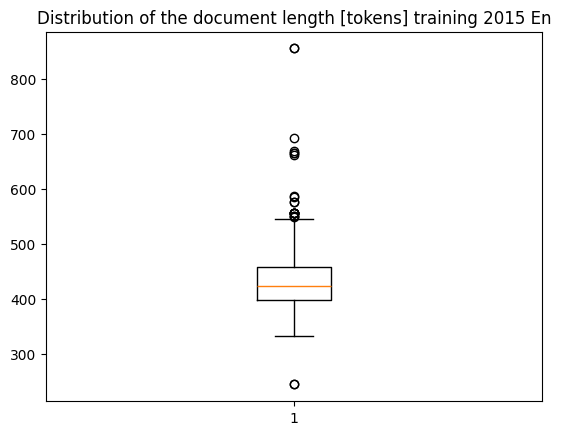

0
100
200
300
400
500
600
700
800
900
[384, 414, 995, 339, 402, 445, 482, 414, 352, 396, 1086, 373, 995, 421, 913, 439, 898, 836, 384, 368, 819, 937, 684, 814, 628, 445, 819, 939, 564, 1206, 454, 368, 898, 442, 564, 345, 913, 426, 402, 345, 638, 682, 402, 821, 352, 350, 454, 366, 491, 436, 384, 366, 819, 390, 898, 373, 819, 465, 995, 433, 454, 411, 449, 937, 449, 637, 465, 821, 1082, 426, 449, 397, 1082, 415, 454, 339, 415, 411, 761, 410, 1082, 791, 761, 373, 819, 836, 449, 373, 995, 396, 482, 891, 465, 469, 819, 682, 1086, 883, 684, 836, 898, 891, 1082, 366, 1082, 410, 628, 937, 684, 791, 1103, 1206, 402, 439, 995, 445, 819, 1076, 1103, 436, 1103, 891, 684, 373, 415, 373, 761, 414, 628, 369, 491, 891, 384, 883, 913, 343, 564, 465, 564, 414, 1086, 410, 898, 383, 1086, 433, 1082, 422, 913, 382, 684, 821, 402, 369, 352, 920, 1082, 339, 995, 399, 1103, 415, 564, 436, 761, 369, 761, 411, 684, 883, 913, 410, 465, 436, 995, 439, 898, 421, 995, 354, 1103, 422, 986, 1076, 898, 436, 564, 383, 1

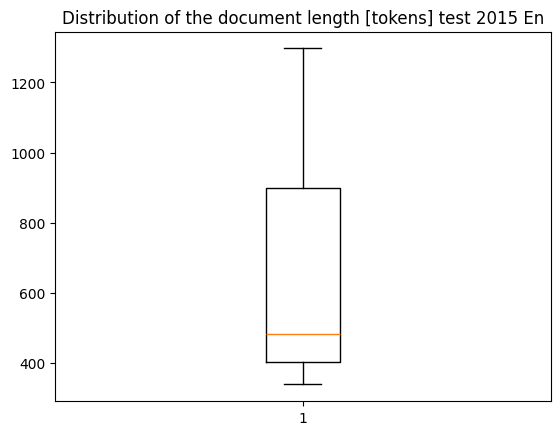

-------------------------------------------------------------------
Training summary
(('n docs', 200), ('Distinct tokens: ', 5181), ('Document average length [tokens]: ', 440.24), ('Distinct tokens per document (average): ', 195.87))
-------------------------------------------------------------------
-------------------------------------------------------------------
Test summary
(('n docs', 1000), ('Distinct tokens: ', 4825), ('Document average length [tokens]: ', 634.5890000000014), ('Distinct tokens per document (average): ', 246.171))
-------------------------------------------------------------------


In [ ]:
info1 = show_info(X_train, 'training', f'{year} {language}')
info2 = show_info(X_test, 'test', f'{year} {language}')

debug(info1, 'Training summary')
debug(info2, 'Test summary')

In [ ]:
puncs = string.punctuation
puncs

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
def get_punctuation_symbols(X_train, X_test):
    # Calculate counts for the punctiation symbols
    # in both training and test data splits.

    punctuations = string.punctuation

    # Punctuation counts
    pcounts_training = dict()
    pcounts_test = dict()

    for sequence in X_train:
        for punc in punctuations:
            times = sequence.count(punc)
            try:
                pcounts_training[punc] += times
            except:
                pcounts_training[punc] = times
    for sequence in X_test:
        for punc in punctuations:
            times = sequence.count(punc)
            try:
                pcounts_test[punc] += times
            except:
                pcounts_test[punc] = times
    return pcounts_training, pcounts_test

In [ ]:
#punctuation counts
pcounts_training, pcounts_test = get_punctuation_symbols(X_train, X_test)

In [ ]:

# sorted punctuation counts
spcounts_training = [(p, c) for (p, c) in sorted(pcounts_training.items(), key=lambda x: x[1]) if c != 0]
spcounts_test = [(p, c) for (p, c) in sorted(pcounts_test.items(), key=lambda x: x[1]) if c != 0]

debug(spcounts_training[-1], 'Most frequent punctuation in training')
debug(spcounts_training[len(spcounts_training) // 2], 'Median count punctuation in training')
debug(spcounts_training[0], 'Least frequent punctuation in training')

debug(spcounts_test[-1], 'Most frequent punctuation in test')
debug(spcounts_test[len(spcounts_test) // 2], 'Median count punctuation in test')
debug(spcounts_test[0], 'Least frequent punctuation in test')

-------------------------------------------------------------------
Most frequent punctuation in training
('.', 49854)
-------------------------------------------------------------------
-------------------------------------------------------------------
Median count punctuation in training
('#', 77)
-------------------------------------------------------------------
-------------------------------------------------------------------
Least frequent punctuation in training
('+', 1)
-------------------------------------------------------------------
-------------------------------------------------------------------
Most frequent punctuation in test
('.', 21039)
-------------------------------------------------------------------
-------------------------------------------------------------------
Median count punctuation in test
('*', 102)
-------------------------------------------------------------------
-------------------------------------------------------------------
Least frequent 

In [ ]:
nltk.download('averaged_perceptron_tagger')

def get_pos_tags(X_train, X_test):
    # return POS tag counts in dictionary
    # for each of the data splits


    pos_dict_training = {}
    pos_dict_test = {}
    for sequence in X_train:
        tokens = nltk.word_tokenize(sequence)
        pos_tags = nltk.pos_tag(tokens)
        for _, pos in pos_tags:
            try:
                pos_dict_training[pos] += 1
            except:
                pos_dict_training[pos] = 1
    for sequence in X_test:
        tokens = nltk.word_tokenize(sequence)
        pos_tags = nltk.pos_tag(tokens)
        for _, pos in pos_tags:
            try:
                pos_dict_test[pos] += 1
            except:
                pos_dict_test[pos] = 1
    return pos_dict_training, pos_dict_test


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
pos_dict_training, pos_dict_test = get_pos_tags(X_train, X_test)

In [ ]:
# Sorted POS tags count in training
sposc_training = [(p, c) for (p, c) in sorted(pos_dict_training.items(), key=lambda x: x[1]) if c != 0]
sposc_test = [(p, c) for (p, c) in sorted(pos_dict_test.items(), key=lambda x: x[1]) if c != 0]

debug(sposc_training[-1], 'Most frequent pos tag in training')
debug(sposc_training[len(sposc_training) // 2], 'Median frequency pos tag in training')
debug(sposc_training[0], 'Least frequent pos tag in training')

debug(sposc_test[-1], 'Most frequent pos tag in test')
debug(sposc_test[len(sposc_test) // 2], 'Median frequency pos tag in test')
debug(sposc_test[0], 'Least frequent pos tag in test')

-------------------------------------------------------------------
Most frequent pos tag in training
('NN', 82065)
-------------------------------------------------------------------
-------------------------------------------------------------------
Median frequency pos tag in training
('MD', 6084)
-------------------------------------------------------------------
-------------------------------------------------------------------
Least frequent pos tag in training
('$', 10)
-------------------------------------------------------------------
-------------------------------------------------------------------
Most frequent pos tag in test
('NN', 35793)
-------------------------------------------------------------------
-------------------------------------------------------------------
Median frequency pos tag in test
('MD', 2681)
-------------------------------------------------------------------
-------------------------------------------------------------------
Least frequent pos 

In [ ]:
#%%capture
nltk.download('tagsets')
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


In [ ]:
def zipfs_law(X, title, x_label, y_label):

    plt.figure(figsize=(10, 5))
    plt.title('Zipf`s law ' + title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)


    merged_texts = ''.join(X)

    tokens = nltk.word_tokenize(merged_texts)
    token_counter = Counter(tokens)
    stoken_counter = sorted(token_counter.items(), key=lambda item: \
                                item[1], reverse=True)

    log_freqs = np.log(np.array([item[1] for item in stoken_counter]))[1:]
    log_ranks = np.log(np.array([i for i in range(len(stoken_counter))]))[1:]
    #log_ranks[log_ranks == np.float('-inf')] = -100

    print(log_ranks.shape)
    print(log_freqs.shape)

    print(log_freqs[:5])
    print(log_ranks[:5])

    m, b = np.polyfit(log_ranks, log_freqs, 1)

    print(m, b)

    #add linear regression line to scatterplot

    plt.scatter(log_ranks, log_freqs, c='blue', label='all words')
    plt.plot(log_ranks, m*log_ranks+b, c='green', label='Zipf ideal case')
    plt.legend()
    #plt.plot([0, 4], [4, 0])

    plt.show()

(24894,)
(24894,)
[10.36637215 10.33224592 10.00188387  9.67683786  9.66586468]
[0.         0.69314718 1.09861229 1.38629436 1.60943791]
-1.362909654955989 13.518287084485925


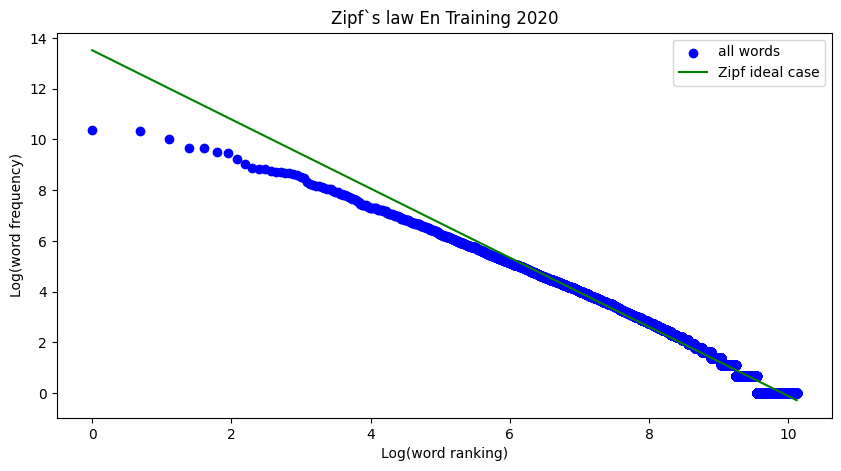

In [ ]:

zipfs_law(X_train, f'{language} Training {year}', 'Log(word ranking)', 'Log(word frequency)')

(16301,)
(16301,)
[9.49619578 9.48341629 9.1026438  8.80131895 8.79664146]
[0.         0.69314718 1.09861229 1.38629436 1.60943791]
-1.2600509680514262 11.918348195021194


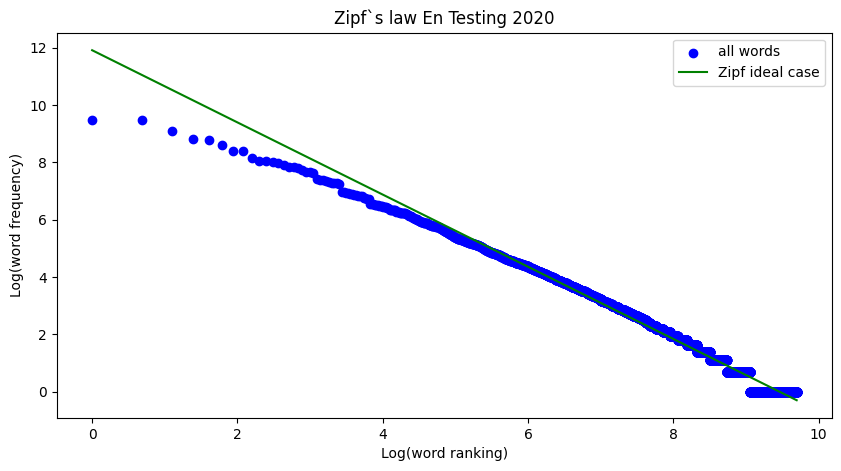

In [ ]:
zipfs_law(X_test, f'{language} Testing {year}', 'Log(word ranking)', 'Log(word frequency)')